In [ ]:
import anndata as ad
import pandas as pd
from pathlib import Path

# -------------------------
# Paths (ajusta si es necesario)
# -------------------------
gene_path = Path("/work3/s252608/DL_project/data/raw/bulk_processed_genes.h5ad")
tx_path = Path("/work3/s252608/DL_project/data/raw/bulk_processed_transcripts.h5ad")
qc_path = Path("/work3/s252608/DL_project/data/qc/bulk_mock_gene_summary_metrics.csv")

# -------------------------
# Load AnnData (backed mode to save memory)
# -------------------------
adata_gene = ad.read_h5ad(gene_path, backed="r")
adata_tx = ad.read_h5ad(tx_path, backed="r")

print("Gene shape:", adata_gene.shape)
print("Transcript shape:", adata_tx.shape)

# -------------------------
# Load QC dataframe
# -------------------------
df = pd.read_csv(qc_path)

print("QC dataframe:", df.shape)

In [3]:
print(df.columns.tolist())
print()
print(df.isna().sum().sort_values(ascending=False))

['gene_id', 'n_isoforms', 'n_valid_samples', 'mean_gene_expr', 'mean_sum_iso_expr', 'mean_abs_error', 'corr_gene_vs_sum_iso', 'median_rel_error', 'p90_rel_error', 'mean_ratio_sumTx_to_gene', 'median_ratio_sumTx_to_gene', 'p10_ratio_sumTx_to_gene', 'p90_ratio_sumTx_to_gene', 'fraction_gene_detected', 'fraction_sum_iso_detected', 'max_mean_isoform_proportion', 'mean_dominant_fraction', 'std_dominant_fraction', 'p90_dominant_fraction', 'mean_entropy', 'std_entropy', 'p10_entropy', 'p90_entropy']

gene_id                        0
n_isoforms                     0
n_valid_samples                0
mean_gene_expr                 0
mean_sum_iso_expr              0
mean_abs_error                 0
corr_gene_vs_sum_iso           0
median_rel_error               0
p90_rel_error                  0
mean_ratio_sumTx_to_gene       0
median_ratio_sumTx_to_gene     0
p10_ratio_sumTx_to_gene        0
p90_ratio_sumTx_to_gene        0
fraction_gene_detected         0
fraction_sum_iso_detected      0
max_me

In [4]:
cols = [
    "corr_gene_vs_sum_iso",
    "median_ratio_sumTx_to_gene",
    "p90_ratio_sumTx_to_gene",
    "fraction_gene_detected",
    "fraction_sum_iso_detected",
    "mean_entropy",
    "mean_dominant_fraction",
    "n_isoforms",
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
corr_gene_vs_sum_iso,100.0,2.160767e-01,2.611215e-01,-0.127788,0.019864,0.148777,3.012973e-01,9.960262e-01
median_ratio_sumTx_to_gene,100.0,6.740000e+12,3.672980e+13,0.000000,0.020302,0.452158,6.808732e+00,2.880000e+14
p90_ratio_sumTx_to_gene,100.0,8.179093e+13,3.107220e+14,0.002174,0.931466,6.324993,5.324993e+12,2.470697e+15
fraction_gene_detected,100.0,8.169000e-01,2.709251e-01,0.070000,0.768750,0.960000,9.950000e-01,1.000000e+00
fraction_sum_iso_detected,100.0,8.416500e-01,2.123308e-01,0.120000,0.731250,0.960000,9.900000e-01,1.000000e+00
mean_entropy,100.0,3.367874e-01,1.705194e-01,0.025753,0.213312,0.333647,4.564889e-01,7.557244e-01
mean_dominant_fraction,100.0,7.839404e-01,1.397767e-01,0.436994,0.703373,0.789373,8.927147e-01,9.919974e-01
n_isoforms,100.0,4.710000e+00,2.523806e+00,2.000000,3.000000,4.000000,6.250000e+00,1.000000e+01


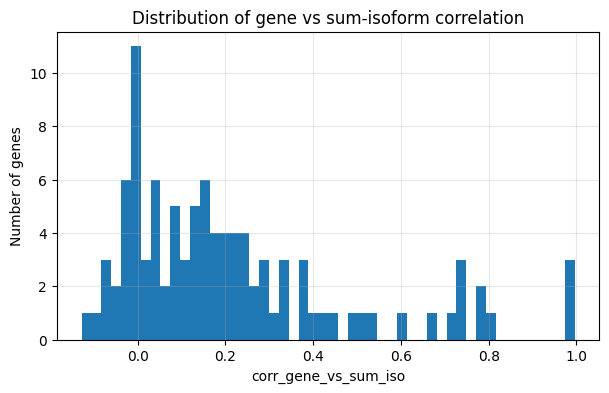

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(df["corr_gene_vs_sum_iso"].dropna(), bins=50)
plt.xlabel("corr_gene_vs_sum_iso")
plt.ylabel("Number of genes")
plt.title("Distribution of gene vs sum-isoform correlation")
plt.grid(alpha=0.3)
plt.show()

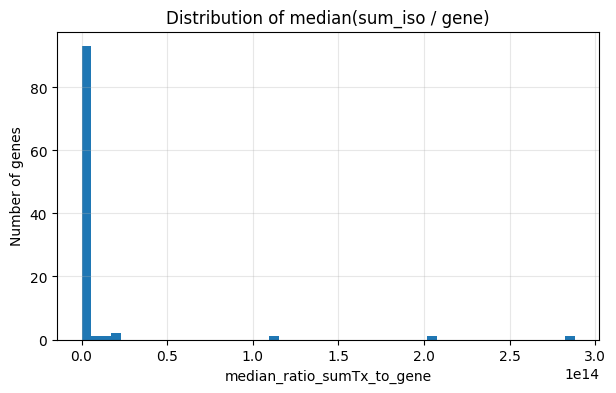

In [6]:
x = df["median_ratio_sumTx_to_gene"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(7, 4))
plt.hist(x, bins=50)
plt.xlabel("median_ratio_sumTx_to_gene")
plt.ylabel("Number of genes")
plt.title("Distribution of median(sum_iso / gene)")
plt.grid(alpha=0.3)
plt.show()

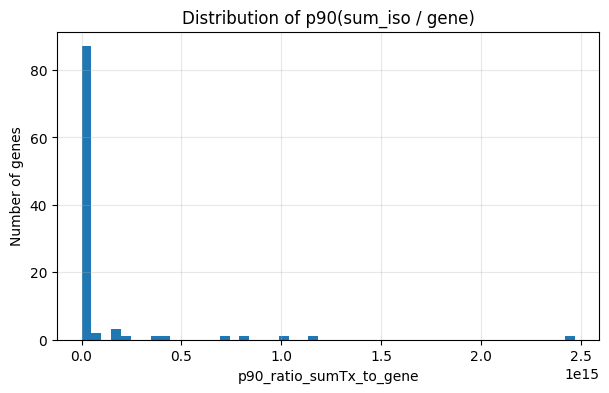

In [7]:
x = df["p90_ratio_sumTx_to_gene"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(7, 4))
plt.hist(x, bins=50)
plt.xlabel("p90_ratio_sumTx_to_gene")
plt.ylabel("Number of genes")
plt.title("Distribution of p90(sum_iso / gene)")
plt.grid(alpha=0.3)
plt.show()

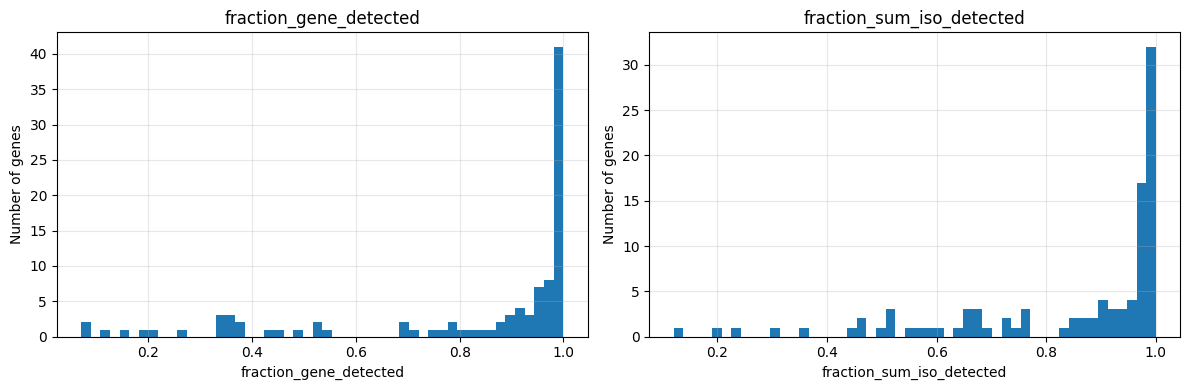

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["fraction_gene_detected"].dropna(), bins=50)
axes[0].set_title("fraction_gene_detected")
axes[0].set_xlabel("fraction_gene_detected")
axes[0].set_ylabel("Number of genes")
axes[0].grid(alpha=0.3)

axes[1].hist(df["fraction_sum_iso_detected"].dropna(), bins=50)
axes[1].set_title("fraction_sum_iso_detected")
axes[1].set_xlabel("fraction_sum_iso_detected")
axes[1].set_ylabel("Number of genes")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# 1. Load gene-to-transcript mapping
# -------------------------
mapping_path = Path("/work3/s252608/DL_project/data/bulk_gene_to_transcripts.json")

with open(mapping_path) as f:
    gene_to_tx = json.load(f)

print(f"Loaded mapping for {len(gene_to_tx)} genes")


# -------------------------
# 2. Validate AnnData alignment
# -------------------------
assert adata_gene.n_obs == adata_tx.n_obs, "Mismatch in number of samples"
assert (adata_gene.obs_names == adata_tx.obs_names).all(), "Sample order mismatch"


# -------------------------
# 3. Select a problematic gene from QC results
# -------------------------
df_clean = df.replace([np.inf, -np.inf], np.nan)

bad_genes = df_clean[
    (df_clean["corr_gene_vs_sum_iso"] < 0.3) |
    (~df_clean["median_ratio_sumTx_to_gene"].between(0.5, 1.5))
].dropna(subset=["corr_gene_vs_sum_iso"])

gene_id = bad_genes.sort_values("corr_gene_vs_sum_iso").iloc[0]["gene_id"]
print(f"Selected gene: {gene_id}")


# -------------------------
# 4. Get transcripts for the gene
# -------------------------
if gene_id not in gene_to_tx:
    raise ValueError(f"{gene_id} not found in mapping")

tx_list = gene_to_tx[gene_id]
tx_list = [t for t in tx_list if t in adata_tx.var_names]

if len(tx_list) == 0:
    raise ValueError(f"No transcripts found for {gene_id} in adata_tx")

print(f"Number of transcripts: {len(tx_list)}")


# -------------------------
# 5. Extract expression data
# -------------------------
g_expr = adata_gene[:, gene_id].X.toarray().ravel()
tx_matrix = adata_tx[:, tx_list].X.toarray()

sum_tx = tx_matrix.sum(axis=1)


# -------------------------
# 6. Build comparison dataframe
# -------------------------
eps = 1e-8

df_example = pd.DataFrame({
    "gene_expr": g_expr,
    "sum_iso_expr": sum_tx,
    "ratio": sum_tx / (g_expr + eps),
    "abs_error": np.abs(g_expr - sum_tx),
})

print("\nPreview:")
print(df_example.head())


# -------------------------
# 7. Inspect extreme cases
# -------------------------
print("\nTop cases: isoforms >> gene")
print(df_example.sort_values("ratio", ascending=False).head(10))

print("\nTop cases: gene >> isoforms")
print(df_example.sort_values("ratio", ascending=True).head(10))


# -------------------------
# 8. Scatter plot (key diagnostic)
# -------------------------
plt.figure(figsize=(5, 5))
plt.scatter(g_expr, sum_tx, alpha=0.5, s=10)

max_val = max(g_expr.max(), sum_tx.max())
plt.plot([0, max_val], [0, max_val], 'r--')

plt.xlabel("Gene expression")
plt.ylabel("Sum of transcript expression")
plt.title(f"{gene_id}: gene vs transcript sum")
plt.grid(alpha=0.3)
plt.show()


# -------------------------
# 9. Ratio distribution
# -------------------------
ratio = sum_tx / (g_expr + eps)
ratio = ratio[np.isfinite(ratio)]

plt.figure(figsize=(6, 4))
plt.hist(ratio, bins=100)
plt.xlabel("sum(transcripts) / gene")
plt.ylabel("Count")
plt.title(f"{gene_id}: ratio distribution")
plt.grid(alpha=0.3)
plt.show()


# -------------------------
# 10. Inspect transcript contributions in a problematic sample
# -------------------------
iso_df = pd.DataFrame(tx_matrix, columns=tx_list)

idx = df_example["ratio"].idxmax()

print(f"\nExtreme sample index: {idx}")
print(f"Gene expression: {g_expr[idx]}")
print(f"Sum of transcripts: {sum_tx[idx]}")

print("\nTop contributing transcripts:")
print(iso_df.iloc[idx].sort_values(ascending=False).head(10))

Loaded mapping for 45263 genes


NameError: name 'adata_gene' is not defined